In [1]:
import matplotlib.pyplot as plt
import numpy as np
#%matplotlib inline
import pandas as pd
import scipy.optimize as so

import sys
import os
sys.path.insert(1, os.path.abspath('../../general_functions'))
from nb_toc import toc, back_to_toc, setup
setup()

toc([
    "Part 0: read in the data for your planet",
    "Part 1: measuring planet mass using RV data",
    "Part 2: measuring planet mass from a light curve",
    "Part 3: interpreting the planet",
    "Part 4: choose your own adventure",
    ])

<IPython.core.display.Javascript object>

You have been assigned an exoplanet: GJ 1214 b or HD 189733 b. Your job is to estimate the mass, radius, and density of the planet using radial velocity and transit light curve data and place these values in a broader exoplanet context. 

## Part 0: read in the data for your planet
Comment out the planet that isn't yours!!!

In [4]:
planet = 'GJ1214b'
#planet = 'HD189733b'

if planet == 'GJ1214b':
    rv_data = pd.read_csv('./data/GJ1214b_RVC.csv')
    lc_data = pd.read_csv('./data/GJ1214b_PLC.csv')
    lc_data['BJD'] = lc_data['BJD'] - 2450000.0
    tc = 2455701.413328 - 2450000.0
    per = 1.58040433

    rv_data['orb_phase'] = ((rv_data['BJD'] - tc) / per) - round(((rv_data['BJD'] - tc) / per), 0)
    lc_data['orb_phase'] = ((lc_data['BJD'] - tc) / per) - round(((lc_data['BJD'] - tc) / per), 0)
    
else:
    rv_data = pd.read_csv('./data/HD189733b_RVC.csv')
    lc_data = pd.read_csv('./data/HD189733b_PLC.csv')
    tc_hjd = 2453937.7759
    tc_bjd = 2454403.677711
    per = 2.21857567

    rv_data['orb_phase'] = ((rv_data['JD'] - tc_hjd) / per) - round(((rv_data['JD'] - tc_hjd) / per), 0)
    lc_data['orb_phase'] = ((lc_data['BJD'] - tc_bjd) / per) - round(((lc_data['BJD'] - tc_bjd) / per), 0)



## Part 1: measuring planet mass using RV data

In [6]:
def sine_func(orb_phase, K, x0):
    return K*np.sin((orb_phase-x0)*2.0*np.pi)

params, covariance = so.curve_fit(sine_func, rv_data['orb_phase'], rv_data['RVel'])


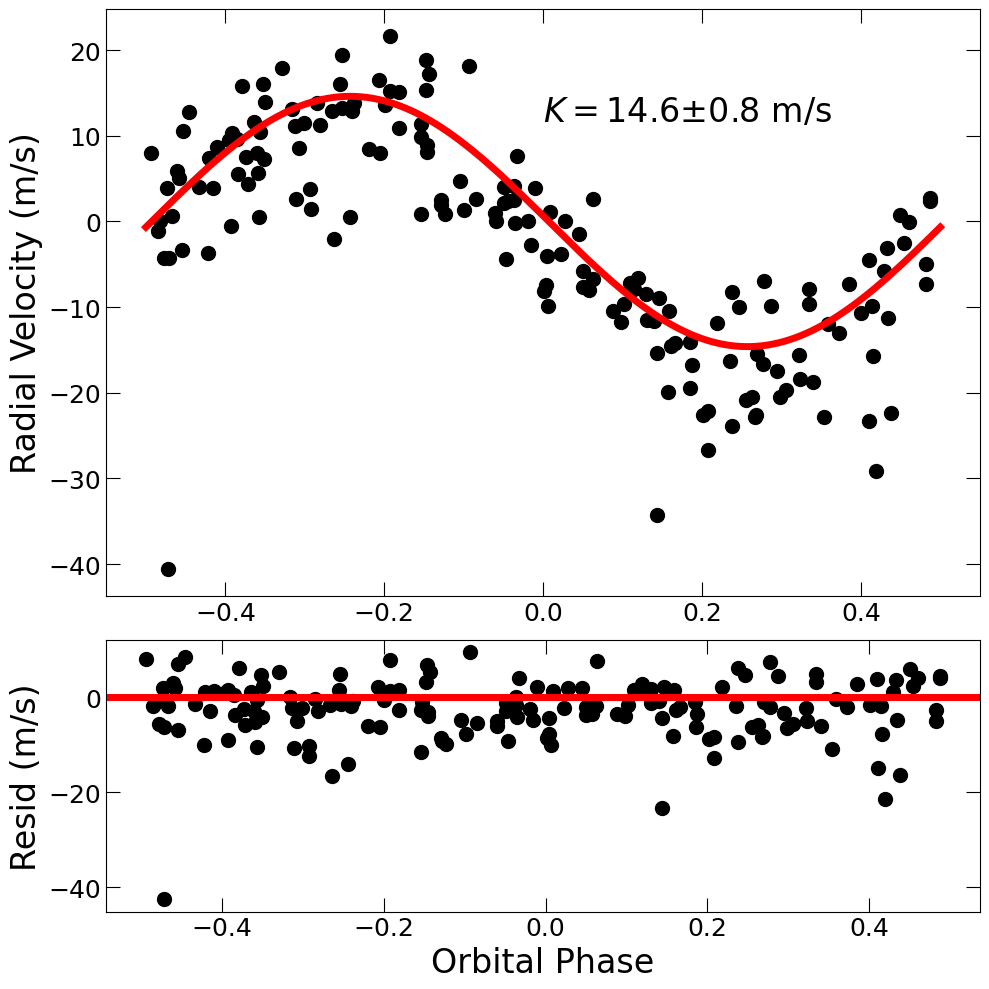

In [7]:
fig = plt.figure(figsize = (10,10))
ax1 = plt.subplot2grid((3, 2), (0, 0), colspan=2, rowspan = 2)
ax2 = plt.subplot2grid((3, 2), (2, 0), colspan=2, rowspan = 1)


ax1.plot(rv_data['orb_phase'], rv_data['RVel'], 'ko', markersize = 10)
x = np.linspace(-0.5, 0.5, 1000)
ax1.plot(x, sine_func(x, params[0], params[1]), 'r-', lw = 5)
ax1.text(0., 0.8*abs(params[0]), r'$K = $' + str(round(abs(params[0]), 1)) + r'$\pm$' +  str(round(covariance[0,0]**0.5, 1))
         + ' m/s', fontsize = 24)
ax1.tick_params(which = 'both', direction = 'in', labelsize = 18, length = 10, top = True, right = True)
ax1.set_ylabel('Radial Velocity (m/s)', fontsize = 24)


ax2.plot(rv_data['orb_phase'], rv_data['RVel'] - sine_func(rv_data['orb_phase'], params[0], params[1]), 'ko', markersize = 10)
ax2.set_xlabel('Orbital Phase', fontsize = 24)
ax2.set_ylabel('Resid (m/s)', fontsize = 24)
ax2.tick_params(which = 'both', direction = 'in', labelsize = 18, length = 10, top = True, right = True)

ax2.axhline(0, color = 'r', lw = 5)
#ax2.set_xlim(-0.025, 0.025)

plt.tight_layout()

#ax2.set_xlim(-0.0251, 0.025)





### What you need to do for this part of the project: 
    1.) Use the NASA Exoplanet Archive (NEA) and your notes to convert the semi-amplitude into a mass for the planet. 
    2.) Calculate the uncertainty in planet mass using standard propogation of uncertainties. 
        You will need to consider the uncertainties in host star mass and semi-amplitude. You can neglect the uncertainties 
        in semi-major axis and/or orbital period for the sake of this calulcation. Why?
    3.) How does your mass measurement compare to those measured in the literature? (quantify)
    4.) Discuss the assumptions we are making by fitting the data to a sine curve. I have selected planets so their RV data are well approximated by a sine curve. You should discuss the conditions that must be met for this to be the case. 
    
    Other notes: in your report you should quote the mass of the planet in either Earth masses or Jupiter masses (whichever
    makes more sense for your planet). Do not give me the mass in kg, g, etc!
    

## Part 2: measuring planet mass from a light curve

In [10]:
def lc_model(time, f0, d, tau, T, tc):
    y = np.zeros(len(time))
    i = 0
    for t in time:
        if abs(t-tc) <= (T/2.0) - tau/2.0:
            y[i] = f0-d
        if (T/2.0 - tau/2.0 < abs(t-tc)) and (abs(t-tc) < T/2.0 + tau/2.0):
            y[i] = f0 - d + (d/tau)*(abs(t-tc) - T/2.0 + tau/2.0)
        if abs(t-tc) >= T/2.0 + tau/2.0:
            y[i] = f0
        i += 1
    return y

In [11]:
params, cov = so.curve_fit(lc_model,lc_data['orb_phase'], lc_data['norm_flux'], p0 = [1.0, 0.3, 0.01, 0.02, 0.0])

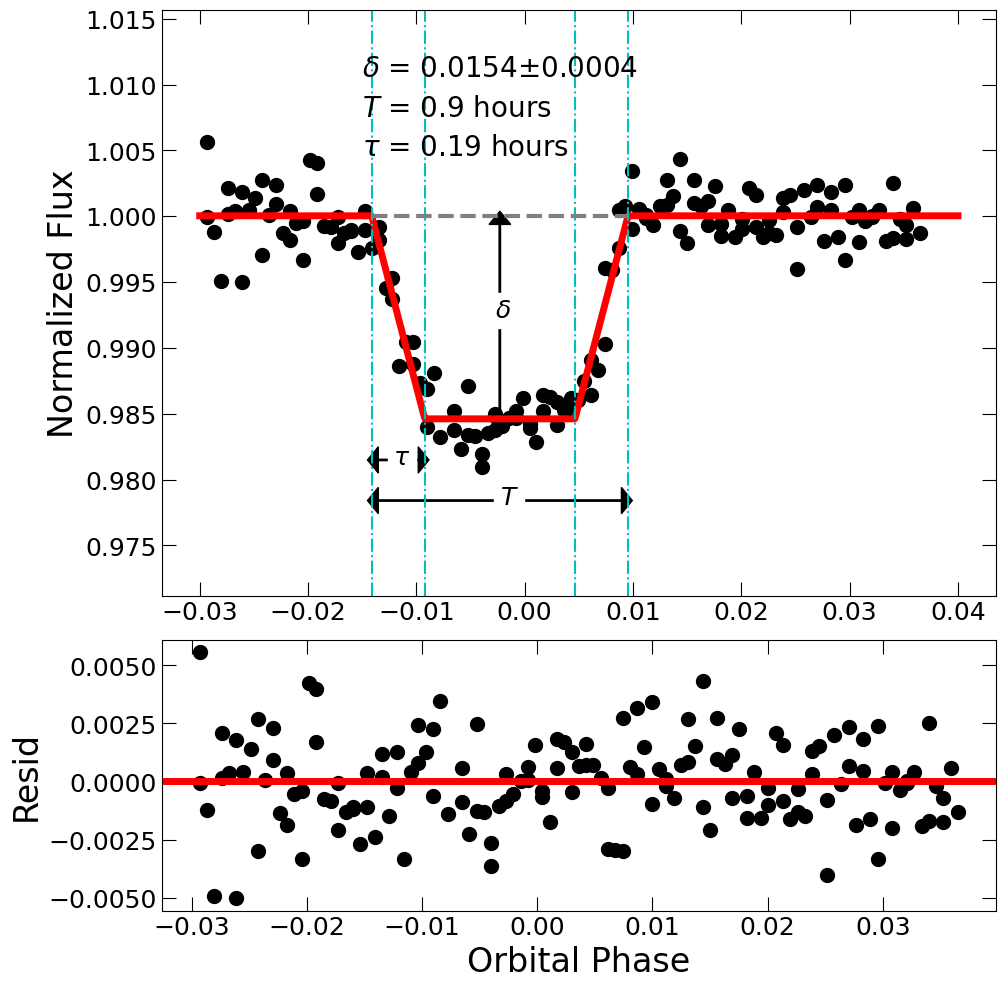

In [12]:
fig = plt.figure(figsize = (10,10))
ax1 = plt.subplot2grid((3, 2), (0, 0), colspan=2, rowspan = 2)
ax2 = plt.subplot2grid((3, 2), (2, 0), colspan=2, rowspan = 1)

ax1.plot(lc_data['orb_phase'], lc_data['norm_flux'], 'ko', markersize = 10)

x = np.linspace(-0.03, 0.04, 1000)
ax1.plot(x, lc_model(x, params[0], params[1], params[2], params[3], params[4]), 'r-', lw = 5)

ax1.tick_params(which = 'both', direction = 'in', labelsize = 18, length = 10, top = True, right = True)
ax1.set_ylabel('Normalized Flux', fontsize = 24)


ax1.axvline(params[4]-params[3]/2.0 - params[2]/2.0, linestyle = '-.', color = 'c')
ax1.axvline(params[4]-params[3]/2.0 + params[2]/2.0, linestyle = '-.', color = 'c')

ax1.axvline(params[4] + params[3]/2.0 + params[2]/2.0, linestyle = '-.', color = 'c')
ax1.axvline(params[4] + params[3]/2.0 - params[2]/2.0, linestyle = '-.', color = 'c')

ax1.arrow(params[4]-params[3]/2.0, 1.0 - 1.2*params[1], 0.75*params[2]/2.0, 0, width = 0.0001, color = 'k', head_length = 0.001, head_width = 0.002)
ax1.arrow(params[4]-params[3]/2.0, 1.0 - 1.2*params[1], -0.75*params[2]/2.0, 0, width = 0.0001, color = 'k', head_length = 0.001, head_width = 0.002)
ax1.text(params[4] - 1.05*params[3]/2.0, 1.0 - 1.22*params[1], r'$\tau$', fontsize = 18, backgroundcolor = 'w')


ax1.arrow(params[4], 1.0 - 1.4*params[1], params[3]/2.0 + 0.75*params[2]/2.0, 0, width = 0.0001, color = 'k', head_length = 0.001, head_width = 0.002)
ax1.arrow(params[4], 1.0 - 1.4*params[1], -(params[3]/2.0 + 0.75*params[2]/2.0), 0, width = 0.0001, color = 'k', head_length = 0.001, head_width = 0.002)
ax1.text(params[4], 1.0 - 1.42*params[1], r'$T$', fontsize = 18, backgroundcolor = 'w')


ax1.plot([params[4] - params[3]/2.0 - params[2]/2.0, params[4] + (params[3]/2.0) + params[2]/2.0] , 
         [1.0, 1.0], color = 'gray', ls = '--', lw = 3)

ax1.arrow(params[4], 1.0 - 1.04*params[1], 0, params[1], width = 0.0001, color = 'k', head_length = 0.001, head_width = 0.002)
ax1.arrow(params[4], 1.0, 0, -params[1], width = 0.0001, color = 'k', head_length = 0.001, head_width = 0.002)
ax1.text(1.2*params[4], 1.0 - 0.5*params[1], r'$\delta$', fontsize = 18, backgroundcolor = 'w')




ax1.set_ylim(0.99*min(lc_data['norm_flux']), 1.01*max(lc_data['norm_flux']))


ax1.text(-0.015, 1.005*max(lc_data['norm_flux']), r'$\delta$ = ' + str(round(params[1], 4)) + r'$\pm$' 
         + str(round(cov[1,1]**0.5, 4)), fontsize = 20)


ax1.text(-0.015,  1.002*max(lc_data['norm_flux']), r'$T$ = ' + str(round((params[3] + params[2])*per*24.0, 2)) + ' hours', fontsize = 20)
ax1.text(-0.015,  0.999*max(lc_data['norm_flux']), r'$\tau$ = ' + str(round((params[2])*per*24.0, 2)) + ' hours', fontsize = 20)


ax2.plot(lc_data['orb_phase'], lc_data['norm_flux'] - lc_model(lc_data['orb_phase'], params[0], params[1], params[2], params[3], params[4]), 'ko', markersize = 10)
ax2.tick_params(which = 'both', direction = 'in', labelsize = 18, length = 10, top = True, right = True)

ax2.set_xlabel('Orbital Phase', fontsize = 24)

ax2.set_ylabel('Resid', fontsize = 24)
ax2.axhline(0, color = 'r', lw = 5)

plt.tight_layout()


### What you need to do for this part of the project
    1.) Use the NEA and your notes to convert this transit depth into a radius. 
    2.) Calculate the uncertainty in planet radius using standard propogation of uncertainties. 
        You will need to consider the uncertainties in host star radius and transit depth. Which contributes more to
        the planet radius uncertainty? (quantify)
    3.) How does your radius measurement compare to those measured in the literature? (quantify)
    4.) Describe some of the limitations of this simplistic approach (qualitatively)
    
    Other notes: in your report you should quote the radius of the planet in either Earth radii or Jupiter radii (whichever
    makes more sense for your planet). Do not give me the mass in km, m, cm etc! You should quote density in g/cc or kg/m3.

## Part 3: interpreting the planet

### Once you have both mass and radius estimates:    
    
    1.) Calculate the planet's density and uncertainty. Here you can pick from several different units: g/cc, Earth densities, Jupiter densities, or the scaled densities from the Tour of the Solar System notebook. I recommend starting with just g/cc and then converting to other units for comparisons.
    2.) Compare density, mass, and radius with the Solar System planets. What type of planet do you think this is? Why?
    3.) In your report and presentation, I would like to see a table with the following planet properties: mass, radius,
    density, orbital period, ingress duration, and total transit duration. One column should be the values you calculate and another column should contain the literature values you are comparing with.
    4.) Also make a note of the host star's mass, radius, rotational period, effective temperature -- you don't need to make
    a table of these parameters in your report, but I would like to see them listed in your presentation so we can
    discuss
    5.) A few sentences on anything else notable/interesting about your planet and its star(s).

## Part 4: choose your own adventure

### Doing all of the above will earn you a maximum of 90%. For the remaining 10%, pick one of the following or come up with your own idea (just run it by me first). These are in approx order of difficulty.
Either group:
- Make a mass-radius plot of all exoplanets in the NASA exoplanet archive and overlay your planet (clearly -- make the marker huge and unique). Add the M-R rlationships from https://iopscience.iop.org/article/10.3847/1538-4357/834/1/17/pdf (see Eq. 1 + Table 2). Interpret your planet in the broader context.
    
Specific to HD 189733:
- You should see some wonky residuals near orbital phase = 0. Try to figure out what this effect is called from the literature on this system and describe it qualitatively. It is caused by the planet transiting (a transit in an RV curve ... what?!). Convince yourself this is true: fit a sine function to these residuals to estimate the transit duration of the planet (and uncertainty). Compare this with the transit duration you calculated directly from the light curve. Depending on how good your fit is, the two numbers may not be exactly the same but they should agree to within ~ 10 minutes.
        
Specific to GJ 1214 b:
- Read up a bit on the radius gap (a topic we will cover in more detail later). Make a radius-period plot all planets with all ~ R <= 2 R_earth planets on NEA. Add the radius gap from Van Eylen+ 2018 (https://ui.adsabs.harvard.edu/abs/2018MNRAS.479.4786V/abstract; coefficients given in point ii of the conclusions). Overlay your planet clearly. Interpret and discuss your planet in the context of the radius gap.
        - 
        
        
        